# <font color= "teal" > Assignment: Matplotlib and Data Visualization </font>

**SciPro**: 2026SS_06.

**Date**: 05.07.2026.

**Goal**: The goal of this assignment is to become familiar with the matplotlib modules by exploring some specific data. By doing this, we practice the scientific programming concepts we have learned so far.






I wanted to analyze data about historical data about the Champions League from 2016 to 2022. My focus is on comparing wheter teams have a home advantage when playing without fans. For this I will copare the period during Covind with the perios before and after.I used Kaggle[1] to extract the data.

For this task I am allowed to use Python3[2,3] functions and libraries such as Matplotlib[4], Seaborn[5], NumPy[6], and Pandas[7,8]. I will start by importing the necessary libraries.





In [2]:
import matplotlib.pyplot as plt
import pandas as pd


Now we have to import the data and clean it.

In [7]:
#read data
difference = pd.read_excel('UEFA_Champions_League_20162022_Data.xlsx', sheet_name='matches', header=0)

UEFA Champions League 2016-2022 Data
                            
#clean duplicates and useless values
difference = difference.drop_duplicates()
difference  = difference.dropna()

#create new column
difference['HOME_GOAL_DIFF'] = difference['HOME_TEAM_SCORE'] - difference['AWAY_TEAM_SCORE']

difference.head(10)

,MATCH_ID,SEASON,DATE_TIME,HOME_TEAM,AWAY_TEAM,STADIUM,HOME_TEAM_SCORE,AWAY_TEAM_SCORE,PENALTY_SHOOT_OUT,ATTENDANCE,HOME_GOAL_DIFF
0,mt1,2021-2022,15-SEP-21 08.00.00.000000000 PM,Manchester City,RB Leipzig,Etihad Stadium,6,3,0,38062,3
1,mt2,2021-2022,15-SEP-21 08.00.00.000000000 PM,Club Brugge KV,Paris Saint-Germain,Jan Breydel Stadion,1,1,0,27546,0
2,mt3,2021-2022,28-SEP-21 08.00.00.000000000 PM,Paris Saint-Germain,Manchester City,Parc des Princes,2,0,0,37350,2
3,mt4,2021-2022,28-SEP-21 08.00.00.000000000 PM,RB Leipzig,Club Brugge KV,Red Bull Arena,1,2,0,23500,-1
4,mt5,2021-2022,19-OCT-21 05.45.00.000000000 PM,Club Brugge KV,Manchester City,Jan Breydel Stadion,1,5,0,24915,-4
5,mt6,2021-2022,19-OCT-21 08.00.00.000000000 PM,Paris Saint-Germain,RB Leipzig,Parc des Princes,3,2,0,47359,1
6,mt7,2021-2022,03-NOV-21 08.00.00.000000000 PM,RB Leipzig,Paris Saint-Germain,Red Bull Arena,2,2,0,39794,0
7,mt8,2021-2022,03-NOV-21 08.00.00.000000000 PM,Manchester City,Club Brugge KV,Etihad Stadium,4,1,0,50228,3
8,mt9,2021-2022,24-NOV-21 08.00.00.000000000 PM,Manchester City,Paris Saint-Germain,Etihad Stadium,2,1,0,52030,1
9,mt10,2021-2022,24-NOV-21 08.00.00.000000000 PM,Club Brugge KV,RB Leipzig,Jan Breydel Stadion,0,5,0,24072,-5


We have to create a method, that calculates the difference between the goals scored by the home team and the goals scored by the away team.

In [6]:


def goal_difference(home_scores: pd.Series, away_scores: pd.Series) -> pd.Series:
    ''' Calculates the difference of home goals and away goals of a football match


    Args:
        home_scores: the goals a team scored in their home stadium
        away_scores: the goals a team scored in another stadium


    Return:
          the method returns the difference between home goals and away goals.

    '''


    if not isinstance(home_scores, pd.Series):
        raise TypeError(f'The value for home_scores (i.e. {home_scores}) must be a pd.Series')
    elif not isinstance(away_scores, pd.Series):
        raise TypeError(f'The value for home_scores (i.e. {home_scores}) must be a pd.Series')
    else:
        return home_scores - away_scores



At this point, we save the values we have calculated.

In [9]:
difference['HOME_GOAL_DIFF'] = goal_difference(home_scores=difference['HOME_TEAM_SCORE'],
                               away_scores=difference['AWAY_TEAM_SCORE'])

difference.head(10)

,MATCH_ID,SEASON,DATE_TIME,HOME_TEAM,AWAY_TEAM,STADIUM,HOME_TEAM_SCORE,AWAY_TEAM_SCORE,PENALTY_SHOOT_OUT,ATTENDANCE,HOME_GOAL_DIFF
0,mt1,2021-2022,15-SEP-21 08.00.00.000000000 PM,Manchester City,RB Leipzig,Etihad Stadium,6,3,0,38062,3
1,mt2,2021-2022,15-SEP-21 08.00.00.000000000 PM,Club Brugge KV,Paris Saint-Germain,Jan Breydel Stadion,1,1,0,27546,0
2,mt3,2021-2022,28-SEP-21 08.00.00.000000000 PM,Paris Saint-Germain,Manchester City,Parc des Princes,2,0,0,37350,2
3,mt4,2021-2022,28-SEP-21 08.00.00.000000000 PM,RB Leipzig,Club Brugge KV,Red Bull Arena,1,2,0,23500,-1
4,mt5,2021-2022,19-OCT-21 05.45.00.000000000 PM,Club Brugge KV,Manchester City,Jan Breydel Stadion,1,5,0,24915,-4
5,mt6,2021-2022,19-OCT-21 08.00.00.000000000 PM,Paris Saint-Germain,RB Leipzig,Parc des Princes,3,2,0,47359,1
6,mt7,2021-2022,03-NOV-21 08.00.00.000000000 PM,RB Leipzig,Paris Saint-Germain,Red Bull Arena,2,2,0,39794,0
7,mt8,2021-2022,03-NOV-21 08.00.00.000000000 PM,Manchester City,Club Brugge KV,Etihad Stadium,4,1,0,50228,3
8,mt9,2021-2022,24-NOV-21 08.00.00.000000000 PM,Manchester City,Paris Saint-Germain,Etihad Stadium,2,1,0,52030,1
9,mt10,2021-2022,24-NOV-21 08.00.00.000000000 PM,Club Brugge KV,RB Leipzig,Jan Breydel Stadion,0,5,0,24072,-5


The results need to be grouped so we can calculate the average results for the different years.

In [14]:
seasonal_stats = difference.groupby('SEASON')[['HOME_GOAL_DIFF', 'ATTENDANCE']].mean()

seasonal_stats.head(10)

,HOME_GOAL_DIFF,ATTENDANCE
SEASON,,
2016-2017,0.624000,43198.416000
2017-2018,0.360000,46573.456000
2018-2019,0.464000,49304.352000
2019-2020,0.117647,39925.394958
2020-2021,0.000000,1299.816000
2021-2022,0.224000,34618.832000


Now, we have to visualize our data.

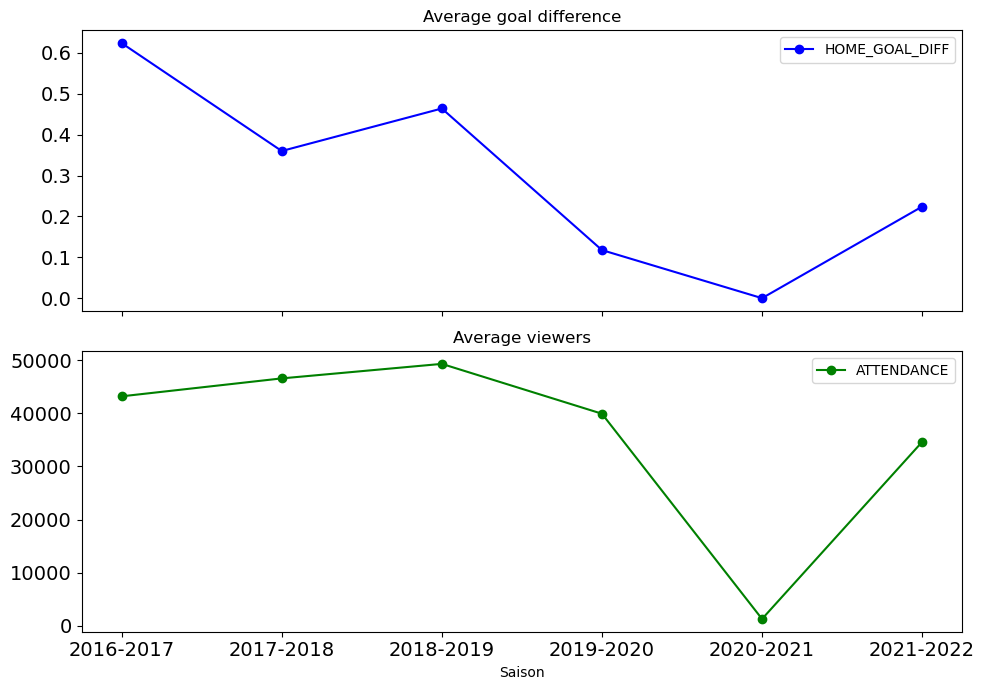

In [12]:
seasonal_stats.plot(kind='line',
                    marker='o',
                    subplots=True,
                    figsize=(10, 7),
                    color=['blue', 'green'],
                    title=['Average goal difference', 'Average viewers'],
                    fontsize=14)


plt.xlabel('Saison')
plt.tight_layout()
plt.show()

In conclusion, the comparison shows that playing in your own stadium has a positive effect on the home team. The goal difference falls when the numer of viewer falls and both significantly. This was especially clear in 2020 and 2021 during the pandemic when fans were not allowed to visit a football game. In those year the average goal difference fell to nearly zero. When the average viewers in a stadium rose. the goal difference did too.

In [13]:
#saving of the data
seasonal_stats.to_csv("final_dataset_champions_league_statistics.csv", sep=";", index=True, encoding="utf-8")

References:



*   [1] Sculley, D. and coworkers, Kaggle. Available at https://www.kaggle.com. Online; accessed on June 13, 2024.

*   [2] Python Software Foundation. Python Language Reference, version 3.12. Available at http://www.python.org. Online; accessed on May 8, 2024.

*  [3] van Rossum, G. Python tutorial, Technical Report CS-R9526, Centrum voor Wiskunde en Informatica (CWI), Amsterdam, 1995.

* [4] Hunter, J.D., 2007. Matplotlib: A 2D graphics environment. IEEE Annals of the History of Computing, 9(03), pp.90-95.

*  [5] Waskom, M. L., 2021. seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021 (DOI: 10.21105/joss.03021).

*  [6] Harris, C.R., Millman, K.J., van der Walt, S.J. et al. Array programming with NumPy. Nature, 585 (2020) 357–362 (DOI: 10.1038/s41586-020-2649-2)

*  [7] The Pandas Development Team pandas-dev/pandas: Pandas Zenodo, 2020 (https://pandas.pydata.org)

*  [8] Pandas user guide, https://pandas.pydata.org/docs/user_guide/index.html#user-guide. Online; accessed on May 8, 2024.

